# CHB_MIT MODEL


In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, GlobalAveragePooling1D, BatchNormalization
from tensorflow.keras.optimizers import Adam

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
ROOT_DIR = "chb"

CLASS_MAP = {
    "interictal": [
        "Non-Seizure/n1"
    ],
    "ictal": ["Seizure/ictal"],
    "postictal": ["Seizure/postictal"]
}

LABEL_MAP = {
    "interictal": 0,
    "ictal": 1,
    "postictal": 2
}


In [ ]:
import numpy as np
import os

def load_eeg_data(root_dir, num_channels=23, fs=256):

    WINDOW_SECONDS = 5
    STRIDE_SECONDS = 1
    
    window_samples = int(fs * WINDOW_SECONDS)  
    stride_samples = int(fs * STRIDE_SECONDS)  
    
    X, y = [], []

    #postictal must come before ictal
    label_from_dir = [
        ("non-seizure", LABEL_MAP["interictal"]),
        ("postictal",   LABEL_MAP["postictal"]),   
        ("ictal",       LABEL_MAP["ictal"]),
    ]

    print(f"Scanning {root_dir}...")
    
    for root, _, files in os.walk(root_dir):
        root_lower = root.lower()

        label = None
        for key, value in label_from_dir:
            if key in root_lower:
                label = value
                break

        if label is None:
            continue

        for file in files:
            if not file.endswith(".csv"):
                continue

            file_path = os.path.join(root, file)

            try:
                
                eeg = np.loadtxt(file_path, delimiter=",")

        
                if eeg.ndim == 1: eeg = eeg.reshape(-1, 1)
             
                if eeg.shape[0] < eeg.shape[1]:
                    eeg = eeg.T

        
                if eeg.shape[1] > num_channels:
                    eeg = eeg[:, :num_channels]
                elif eeg.shape[1] < num_channels:
                    pad_width = num_channels - eeg.shape[1]
                    eeg = np.pad(eeg, ((0, 0), (0, pad_width)), mode="constant")

            
                num_samples = eeg.shape[0]
                
              
                if num_samples < window_samples:
                    continue

                start = 0
                while (start + window_samples) <= num_samples:
                    end = start + window_samples
                    
              
                    window = eeg[start:end, :] 
                    
                    X.append(window)
                    y.append(label)
                    
                    
                    start += stride_samples

            except Exception as e:
                print(f"Error loading {file_path}: {e}")
                continue

    if not X:
        raise ValueError("No valid data files found!")

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    unique, counts = np.unique(y, return_counts=True)
    class_names = list(LABEL_MAP.keys())
    print(f"Generated {len(X)} windows.")
    print("Class distribution:")
    for cls, cnt in zip(unique, counts):
        print(f"  {class_names[cls]} (label {cls}): {cnt} windows")

    return X, y

In [4]:
X, y = load_eeg_data(ROOT_DIR, num_channels=23)

print("X shape (1D CNN input):", X.shape)
print("y shape:", y.shape)


Scanning chb...
Generated 32103 windows.
Class distribution:
  interictal (label 0): 10753 windows
  ictal (label 1): 10753 windows
  postictal (label 2): 10597 windows
X shape (1D CNN input): (32103, 1280, 23)
y shape: (32103,)


In [5]:
print("Final X shape:", X.shape)
print("Input shape for model (1D CNN):", X.shape[1:])

Final X shape: (32103, 1280, 23)
Input shape for model (1D CNN): (1280, 23)


In [6]:
from tensorflow.keras.layers import BatchNormalization
def build(input_shape):
    model = Sequential([

        Conv1D(filters=8, kernel_size=8, strides=1, activation="relu", input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, strides=2),

        Conv1D(filters=16, kernel_size=6, strides=1, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, strides=2),

        Conv1D(filters=16, kernel_size=6, strides=1, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, strides=2),

        Conv1D(filters=32, kernel_size=4, strides=1, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, strides=2),

        Conv1D(filters=64, kernel_size=4, strides=1, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, strides=2),

        GlobalAveragePooling1D(),

        Dense(50, activation="relu"),

        Dense(20, activation="relu"),

        Dense(3, activation="softmax")
    ])
    model.summary()
    return model

In [7]:
X_train, X_Temp, y_train, y_Temp = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  
)

X_test, X_val, y_test, y_val = train_test_split(
    X_Temp, y_Temp,
    test_size=0.5,
    random_state=42,
    stratify=y_Temp
)


print(f"Training shapes: {X_train.shape}, {y_train.shape}")
print(f"Validation shapes: {X_val.shape}, {y_val.shape}")
print(f"Test shapes: {X_test.shape}, {y_test.shape}")

Training shapes: (22472, 1280, 23), (22472,)
Validation shapes: (4816, 1280, 23), (4816,)
Test shapes: (4815, 1280, 23), (4815,)


In [8]:

model = build(input_shape=X.shape[1:])
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nStarting training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)
model.save("eeg_model.keras")
print("Model saved → eeg_model.keras")



y_val_pred_probs = model.predict(X_val, verbose=0)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)

print("-" * 30)
print(f"Final Validation Accuracy: {val_accuracy:.4f}")
print(f"Final Validation Loss: {val_loss:.4f}")




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 1273, 8)           1480      
                                                                 
 batch_normalization (Batch  (None, 1273, 8)           32        
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 636, 8)            0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 631, 16)           784       
                                                                 
 batch_normalization_1 (Bat  (None, 631, 16)           64        
 chNormalization)                                                
                                                      

In [9]:
results = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss:     {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

Test Loss:     0.1851
Test Accuracy: 0.9327


In [10]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# labels=[0,1,2] ensures a 3x3 matrix regardless of which classes appear
all_labels = list(LABEL_MAP.values())   # [0, 1, 2]
class_names = list(LABEL_MAP.keys())    # ['interictal', 'ictal', 'postictal']
cm = confusion_matrix(y_test, y_pred_classes, labels=all_labels)

total = cm.sum()
n_classes = len(all_labels)

print("Per-class Sensitivity :\n")
sensitivities = []
specificities = []

for i in range(n_classes):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = total - tp - fn - fp

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    sensitivities.append(sensitivity)
    specificities.append(specificity)

    print(f"  {class_names[i].capitalize()}")
    print(f"    Sensitivity (Recall) : {sensitivity:.4f}")
    print(f"    Specificity          : {specificity:.4f}")
    print()

print(f"Macro-avg Sensitivity : {np.mean(sensitivities):.4f}")
print(f"Macro-avg Specificity : {np.mean(specificities):.4f}")

151/151 [==============================] - 1s 7ms/step
Per-class Sensitivity :

  Interictal
    Sensitivity (Recall) : 0.9715
    Specificity          : 0.9366

  Ictal
    Sensitivity (Recall) : 0.9337
    Specificity          : 0.9922

  Postictal
    Sensitivity (Recall) : 0.8924
    Specificity          : 0.9702

Macro-avg Sensitivity : 0.9325
Macro-avg Specificity : 0.9663


In [11]:
# ── F1 Score ───────────────────────────────────────────────────────────────────
display_names = [n.capitalize() for n in class_names]

f1_per_class = f1_score(y_test, y_pred_classes, labels=all_labels, average=None)
f1_macro     = f1_score(y_test, y_pred_classes, labels=all_labels, average="macro")
f1_weighted  = f1_score(y_test, y_pred_classes, labels=all_labels, average="weighted")

print("F1 Score per class:")
for name, score in zip(display_names, f1_per_class):
    print(f"  {name:<12} : {score:.4f}")
print(f"\nMacro-avg F1   : {f1_macro:.4f}")
print(f"Weighted-avg F1: {f1_weighted:.4f}")

F1 Score per class:
  Interictal   : 0.9264
  Ictal        : 0.9580
  Postictal    : 0.9140

Macro-avg F1   : 0.9328
Weighted-avg F1: 0.9329


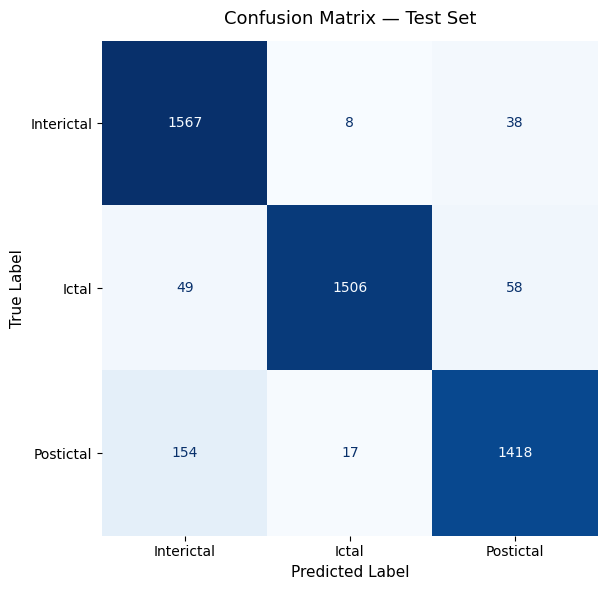

In [ ]:
# ── Confusion Matrix ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
disp.plot(cmap="Blues", colorbar=False, ax=ax)

ax.set_title("Confusion Matrix — Test Set", fontsize=13, pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
# plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()